# CoT Commitment Point Experiment
### Qwen2.5-14B-Instruct | GSM8K | Activation Patching | 4 Semantic Stages

**What this notebook does:**
1. Loads Qwen2.5-14B in NF4 on a single T4 (~10 GB)
2. Collects paired traces from GSM8K: correct (greedy) + wrong (temperature-sampled)
3. For each pair × 4 stages, patches correct-trace activations into wrong-trace forward pass
4. Plots a flip-rate curve — the commitment point signature

**Stages:** `setup → computation → transition → conclusion`  
**Flip rate** = fraction of incorrect traces steered to the correct answer by patching that stage

---
> Set `PILOT_MODE = True` for a ~30 min test on 10 pairs.  
> Set `PILOT_MODE = False` for the full 80-pair run (~3.5 hrs).

## 0 · Install dependencies

In [1]:
# Run once per Kaggle session. Restart kernel after this cell.
!pip install -qU bitsandbytes datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 108.9 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requir

## 1 · Config

In [2]:
import re, json, time
import matplotlib.pyplot as plt
from pathlib import Path
from datasets import load_dataset
from tqdm.auto import tqdm
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# ── Only change these ──────────────────────────────────────────────────────
PILOT_MODE     = True        # True → 10 pairs (~30 min). False → 80 pairs (~3.5 hrs)
N_PAIRS        = 20 if PILOT_MODE else 80
MAX_NEW_TOKENS = 2048
TEMPERATURE    = 1.4         # for sampling wrong traces
SEED           = 42
MODEL_ID       = "Qwen/Qwen2.5-14B-Instruct"
SAVE_DIR       = Path("/kaggle/working")
STAGES         = ["setup", "computation", "transition", "conclusion"]
# ──────────────────────────────────────────────────────────────────────────

torch.manual_seed(SEED)
print(f"PILOT_MODE={PILOT_MODE} | N_PAIRS={N_PAIRS} | device={torch.cuda.get_device_name(0)}")



PILOT_MODE=True | N_PAIRS=20 | device=Tesla T4


## 2 · Load model  (NF4, single T4 — skip if already loaded)

In [3]:
try:
    model
    print(f"Already loaded | GPU0: {torch.cuda.memory_allocated(0)/1e9:.1f} GB")
except NameError:
    print("Loading Qwen2.5-14B-Instruct in NF4...")
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    model     = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        dtype=torch.float16,
        quantization_config=bnb,
        device_map="cuda:0",
    )
    model.eval()

N_LAYERS = len(model.model.layers)   # 48
D_MODEL  = model.config.hidden_size  # 5120

print(f"\n{MODEL_ID}")
print(f"  Layers  : {N_LAYERS}")
print(f"  d_model : {D_MODEL}")
print(f"  GPU 0   : {torch.cuda.memory_allocated(0)/1e9:.2f} GB / {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
if torch.cuda.device_count() > 1:
    print(f"  GPU 1   : {torch.cuda.memory_allocated(1)/1e9:.2f} GB  (should be 0)")
else:
    print(f"  GPU 1   : N/A (single GPU)")


Loading Qwen2.5-14B-Instruct in NF4...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]


Qwen/Qwen2.5-14B-Instruct
  Layers  : 48
  d_model : 5120
  GPU 0   : 9.98 GB / 15.6 GB
  GPU 1   : 0.00 GB  (should be 0)


## 3 · Timing probe
Run this before committing to full collection.  
Prints estimated wall-clock time for your `N_PAIRS` setting.

In [4]:
def make_prompt(question):
    return tokenizer.apply_chat_template(
        [
            {"role": "system", "content": (
                "Solve the math problem step by step, showing all work. "
                "End your solution with: #### [number]"
            )},
            {"role": "user", "content": question},
        ],
        tokenize=False, add_generation_prompt=True,
    )

def gen(prompt, temperature=0.0):
    enc  = tokenizer(prompt, return_tensors="pt").to("cuda:0")
    plen = enc["input_ids"].shape[1]
    kw   = dict(max_new_tokens=MAX_NEW_TOKENS, pad_token_id=tokenizer.eos_token_id)
    if temperature > 0:
        kw.update(do_sample=True, temperature=temperature, top_p=0.9)
    with torch.no_grad():
        out = model.generate(**enc, **kw)
    return tokenizer.decode(out[0][plen:], skip_special_tokens=True)

print("gen() defined")


gen() defined


## 4 · Answer extraction + pair collection

In [5]:
# ── Utility fixes — required by extract_gt, collect_pairs, and patching ──
import re
def normalize_answer(s):
    """Normalize numeric answer: strips $, commas, handles basic LaTeX fractions."""
    if s is None: return None
    s = str(s).strip().lstrip("$").replace(",", "").strip()
    
    # Remove latex math formatting and percentage signs
    s = s.replace('\\$', '').replace('\\%', '').replace('%', '')
    # convert \dfrac{A}{B} or \frac{A}{B} to A/B
    s = re.sub(r'\\(?:d)?frac\{([^{}]+)\}\{([^{}]+)\}', r'\1/\2', s)
    
    try:
        return str(int(float(s)))
    except Exception:
        # Remove any remaining whitespace for robust comparison
        return re.sub(r'\s+', '', s)


def answers_match(a, b):
    """Normalized numeric comparison."""
    return (a is not None and b is not None and
            normalize_answer(a) == normalize_answer(b))


# ── Verify ──
print("Utility fixes applied")
print(f"normalize_answer('120')   = {normalize_answer('120')}")
print(f"normalize_answer('042')   = {normalize_answer('042')}")
print(f"normalize_answer('1,200') = {normalize_answer('1,200')}")
print(f"answers_match('42', '042') = {answers_match('42', '042')}")


Utility fixes applied
normalize_answer('120')   = 120
normalize_answer('042')   = 42
normalize_answer('1,200') = 1200
answers_match('42', '042') = True


In [6]:
# NOTE: _clean_num removed (Bug 7) -- normalize_answer() is the canonical normalizer.

def extract_gt(text):
    if not text: return None
    # FIX Bug 9: Handle \boxed{} with nested braces for MATH dataset
    idx = text.rfind('\\boxed{')
    if idx != -1:
        start = idx + 7
        depth = 1
        for i in range(start, len(text)):
            if text[i] == '{': depth += 1
            elif text[i] == '}': depth -= 1
            if depth == 0:
                val = text[start:i].strip().replace(',', '')
                try: return str(int(float(val)))
                except: return val

    # For model output: #### 42 — use LAST match, not first
    matches = re.findall(r'####\s*\$?(-?[\d,]+(?:\.\d+)?)', text)
    if matches:
        return str(normalize_answer(matches[-1]))

    # Fallback patterns
    m = re.search(r'(?:the\s+answer\s+is|answer\s+is|answer:|final\s+answer\s*(?:is)?|=\s*\$?)\s*\$?(-?[\d,]+(?:\.\d+)?)',
                  text, re.IGNORECASE)
    if m: return str(normalize_answer(m.group(1)))
    return None


# ── Verify all formats ──
print("extract_gt tests:")
print(f"  '#### 15'                        -> {extract_gt('#### 15')}")
print(f"  'The answer is 8 chickens.'      -> {extract_gt('The answer is 8 chickens.')}")
print(f"  'answer is \\boxed{{16}}'          -> {extract_gt(r'answer is \boxed{16}')}")
print(f"  '= $1,200'                       -> {extract_gt('= $1,200')}")
print(f"  'Janet makes $18 every day.'     -> {extract_gt('Janet makes $18 every day.')}")


extract_gt tests:
  '#### 15'                        -> 15
  'The answer is 8 chickens.'      -> 8
  'answer is \boxed{16}'          -> 16
  '= $1,200'                       -> 1200
  'Janet makes $18 every day.'     -> None


In [7]:
def collect_pairs_v3(ds_hard, target_pairs=40, greedy_budget=200, phase1_only=False):
    """Greedy-correct / sampled-wrong collection.
    Phase 1: Scan greedy outputs, keep problems where greedy is CORRECT.
    Phase 2: Sample at high temperatures to find wrong traces.
    Uses a quick pre-screen: if 3 samples at T=1.2 are all correct, skip (too easy).
    """
    pairs = []
    tried = 0
    skipped_easy = 0

    print(f"Phase 1+2: scanning {greedy_budget} problems, target={target_pairs} pairs...")
    
    for item in ds_hard:
        if len(pairs) >= target_pairs:
            break
        if tried >= greedy_budget:
            break
        tried += 1
        q  = item["problem"] if "problem" in item else item["question"]
        gt = extract_gt(item["solution"] if "solution" in item else item["answer"])
        if not gt:
            continue

        prompt = make_prompt(q)
        greedy_out  = gen(prompt, temperature=0.0)
        greedy_pred = extract_gt(greedy_out)

        if greedy_pred is None or not answers_match(greedy_pred, gt):
            continue  # greedy wrong => useless (no correct trace)

        if phase1_only:
            pairs.append({"question": q, "gt": gt, "correct": greedy_out, "source": "organic"})
            print(f"  [{tried}] GT={gt}, greedy=OK")
            continue

        sampled_correct = None
        quick_wrong = False

        # Quick pre-screen: try 3 samples at T=1.2. If all correct, skip (too easy).
        for _ in range(3):
            cand = gen(prompt, temperature=1.2)
            pred = extract_gt(cand)
            if pred is not None and answers_match(pred, gt) and '####' in cand:
                if sampled_correct is None:
                    sampled_correct = cand
            if pred is not None and not answers_match(pred, gt) and '####' in cand:
                _sc = sampled_correct or greedy_out
                pairs.append({
                    "question": q, "gt": gt, "correct": greedy_out,
                    "wrong": cand, "wrong_val": pred, "source": "organic",
                    "sampled_correct": _sc,
                    "sampled_correct_source": "sampled" if sampled_correct else "greedy_fallback",
                })
                print(f"  [{tried}] GT={gt} | PAIR (quick) | wrong={pred} | sc={'sampled' if sampled_correct else 'GREEDY'} | total={len(pairs)}")
                quick_wrong = True
                break
        if quick_wrong:
            continue
        
        # FIX Bug 4: If all 3 pre-screen samples were correct, skip immediately
        # (don't burn 24 more gen calls at escalating temperatures)
        if sampled_correct is not None:
            # All pre-screen attempts produced correct answers -> too easy
            skipped_easy += 1
            if skipped_easy <= 5:
                print(f"  [{tried}] GT={gt} | skipped (too easy, 3/3 correct at T=1.2)")
            continue
        
        # Full sampling: try harder temperatures
        found = False
        for temp in [1.4, 1.6, 1.8, 2.0]:
            for _ in range(6):
                cand = gen(prompt, temperature=temp)
                pred = extract_gt(cand)
                if pred is not None and answers_match(pred, gt) and '####' in cand:
                    if sampled_correct is None:
                        sampled_correct = cand
                if pred is not None and not answers_match(pred, gt) and '####' in cand:
                    # If we haven't found a sampled_correct yet, do a quick pass at T=1.0 to get one
                    if sampled_correct is None:
                        for _ in range(2):
                            c2 = gen(prompt, temperature=1.0)
                            p2 = extract_gt(c2)
                            if p2 is not None and answers_match(p2, gt) and '####' in c2:
                                sampled_correct = c2
                                break
                                
                    _sc = sampled_correct or greedy_out
                    pairs.append({
                        "question": q, "gt": gt, "correct": greedy_out,
                        "wrong": cand, "wrong_val": pred, "source": "organic",
                        "sampled_correct": _sc,
                        "sampled_correct_source": "sampled" if sampled_correct else "greedy_fallback",
                    })
                    print(f"  [{tried}] GT={gt} | PAIR (T={temp}) | wrong={pred} | sc={'sampled' if sampled_correct else 'GREEDY'} | total={len(pairs)}")
                    found = True
                    break
            if found:
                break
        
        if not found:
            skipped_easy += 1
            if skipped_easy <= 5:
                print(f"  [{tried}] GT={gt} | skipped (too easy)")
    
    print(f"\nDone: {len(pairs)} pairs from {tried} problems ({skipped_easy} too-easy skipped)")
    return pairs


In [8]:
from datasets import load_dataset
_diag_temp = 1.2
ds_hard = None

for path, split in [
    ("DigitalLearningGmbH/MATH-lighteval", "test"),   # confirmed working
    ("EleutherAI/hendrycks_math",           "test"),   # fallback
    ("HuggingFaceH4/aime_2024",             "train"),  # AIME if MATH fails (~30 problems)
]:
    try:
        d = load_dataset(path, split=split)
        if "level" in d.column_names:
            d = d.filter(lambda x: x.get("level") in ["Level 4", "Level 5"])
        print(f"✓ {path}: {len(d)} usable problems")
        ds_hard = d
        break
    except Exception as e:
        print(f"✗ {path}: {type(e).__name__}")

# Check error rate on 10 hard problems
errors = 0
for item in ds_hard.select(range(10)):
    q   = item["problem"] if "problem" in item else item["question"]
    gt  = extract_gt(item["solution"] if "solution" in item else item["answer"])
    if not gt: continue
    out = gen(make_prompt(q), temperature=0.0)
    if not answers_match(extract_gt(out), gt):
        errors += 1
        print(f"  Greedy fail: GT={gt}, pred={extract_gt(out)}")

print(f"\nGreedy error rate: {errors}/10")
print("Need >= 4/10 for viable collection")


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/2.99M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.86M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5000 [00:00<?, ? examples/s]

✓ DigitalLearningGmbH/MATH-lighteval: 2538 usable problems
  Greedy fail: GT=x \in [-27], pred=[-2 7]
  Greedy fail: GT=461415, pred=2 5 13 15
  Greedy fail: GT=\frac{11}{2}, pred=5
  Greedy fail: GT=18, pred=2

Greedy error rate: 4/10
Need >= 4/10 for viable collection


### Run pair collection

In [9]:
# ── Trace generation helpers (for sanity check) ──────────────────────
def get_correct_trace(prompt, gt, max_tries=3):
    """Try greedy first. If greedy doesn't produce correct answer,
    fall back to low-temperature sampling."""
    for temp in [0.0, 0.2, 0.3]:
        n_tries = 1 if temp == 0.0 else max_tries
        for _ in range(n_tries):
            trace = gen(prompt, temperature=temp)
            pred  = extract_gt(trace)
            if answers_match(pred, gt):
                return trace
    return None


def generate_wrong_trace(question, gt, correct_trace, max_tries=5):
    """Generate a trace that arrives at the WRONG answer.
    Returns (trace, source) where source is 'organic' or 'injection'.
    Strategy 1: high-temperature sampling.
    Strategy 2: answer-injection (swap final number in correct trace).
    """
    p = make_prompt(question)

    # Strategy 1: sampling
    for _ in range(max_tries):
        cand = gen(p, temperature=TEMPERATURE)
        pred = extract_gt(cand)
        if pred is not None and not answers_match(pred, gt):
            return cand, "organic"

    # Strategy 2: injection fallback
    if correct_trace is None:
        return None, None

    gt_val = normalize_answer(gt)
    try:
        gt_num    = int(gt_val)
        wrong_num = gt_num + 17
    except ValueError:
        return None, None

    import re
    # Try replacing #### format
    inj = re.sub(r'(####\s*)-?[\d,]+', rf'\g<1>{wrong_num}', correct_trace)
    pred = extract_gt(inj)
    if pred is not None and not answers_match(pred, gt):
        return inj, "injection"

    # Try replacing 'the answer is X'
    inj = re.sub(
        r'((?:the\s+answer\s+is|answer\s*(?:is|:))\s*\$?)\s*[\d,]+',
        rf'\g<1>{wrong_num}',
        correct_trace, flags=re.IGNORECASE,
    )
    pred = extract_gt(inj)
    if pred is not None and not answers_match(pred, gt):
        return inj, "injection"

    return None, None


print("Trace helpers defined ✓")


Trace helpers defined ✓


In [10]:
# ── End-to-end sanity check: one pair before committing ────────────────
item    = ds_hard[0]
gt      = extract_gt(item["solution"] if "solution" in item else item["answer"])
q       = item["problem"] if "problem" in item else item["question"]
p       = make_prompt(q)
correct = get_correct_trace(p, gt)
wrong, source = generate_wrong_trace(q, gt, correct)  # unpack tuple

c_ok = answers_match(extract_gt(correct), gt) if correct else False
w_ok = (wrong is not None) and not answers_match(extract_gt(wrong), gt)

print(f"GT      : {gt}")
print(f"Correct : {extract_gt(correct) if correct else 'NONE'}  {'OK' if c_ok else 'FAIL'}")
print(f"Wrong   : {extract_gt(wrong) if wrong else 'NONE'}    {'WRONG (good)' if w_ok else 'FAIL - injection failed'}")
print(f"Source  : {source}")
if wrong:
    print(f"\nWrong trace tail:\n{wrong[-200:]}")

assert c_ok, "Correct trace sanity check failed -- fix get_correct_trace"
assert w_ok, "Wrong trace sanity check failed -- fix generate_wrong_trace"
print("\nSanity check passed -- safe to run collect_pairs()")



GT      : \dfrac{9}{7}
Correct : \dfrac{9}{7}  OK
Wrong   : \frac{2}{7}    WRONG (good)
Source  : organic

Wrong trace tail:
< \frac{2}{7} \leq 3
\]
This holds true if we correctly interpret the floor and ceiling function constraints.

The final answer is:
\[
x = \frac{2}{7}
\]

Final boxed answer:
\[
\boxed{\frac{2}{7}}
\]

Sanity check passed -- safe to run collect_pairs()


In [12]:
# Full collection OR Load from Dataset
dataset_path = Path("/kaggle/input/datasets/aditya26189/aditya-pairs/pairs.json")

if dataset_path.exists():
    print(f"Loading pre-collected pairs from {dataset_path}...")
    with open(dataset_path, "r") as f:
        pairs = json.load(f)
    print(f"Loaded {len(pairs)} pairs instantly!")
else:
    print("Pre-collected pairs not found. Running full collection Phase 1 + 2...")
    t0 = time.time()
    pairs = collect_pairs_v3(ds_hard, target_pairs=N_PAIRS, greedy_budget=600, phase1_only=False)
    t_col = time.time() - t0

    print(f'\nCollected : {len(pairs)} pairs in {t_col/60:.1f} min')
    json.dump(pairs, open(SAVE_DIR / 'pairs.json', 'w'), indent=2)
    print(f'Saved  -> {SAVE_DIR}/pairs.json')
    
# Filter out any pairs that might be "fake wrong" due to old matching rules
old_len = len(pairs)
pairs = [p for p in pairs if not answers_match(p.get("wrong_val"), p["gt"])]
if len(pairs) < old_len:
    print(f"Cleaned up {old_len - len(pairs)} fake-wrong pairs!")

if pairs:
    p0 = pairs[0]
    print(f'\n-- Pair 0 preview --')
    print(f'Question  : {p0["question"][:80]}...')
    print(f'GT answer : {p0["gt"]}')
    print(f'Correct ends with: ...{p0["correct"][-80:]}')
    print(f'Wrong ends with  : ...{p0["wrong"][-80:]}')
    print(f'Source    : {p0.get("source", "?")}')
else:
    print('WARNING: No pairs collected. Check Phase 1 and TEMPERATURE setting.')


Loading pre-collected pairs from /kaggle/input/datasets/aditya26189/aditya-pairs/pairs.json...
Loaded 20 pairs instantly!
Cleaned up 1 fake-wrong pairs!

-- Pair 0 preview --
Question  : Find the sum of all integers that satisfy these conditions: \[
|x|+1>7\text{ and...
GT answer : -15
Correct ends with: ...the sum of all integers that satisfy the given conditions is:
\[ \boxed{-15}. \]
Wrong ends with  : ...e values:
\[ (-8) + (-7) + (-6) = -21 \]

Final Answer:
\(\boxed{-21}\)
#### -21
Source    : organic


## 5 · Stage segmentation
Each line of the wrong trace is classified into one of 4 stages using regex patterns.  
Priority order: `conclusion > computation > transition > setup`.

In [13]:
PATTERNS = {
    "conclusion":  [
        r'####',
        r'\bthe\s+answer\s+is\b',
        r'\bfinal\s+answer\b',
        r'\btherefore.*\banswer\b',
        r'\bin\s+total.*\b(are|is|will\s+be)\b',
    ],
    "computation": [
        r'\d[\d,]*\s*[+\-*/×÷]\s*\d',
        r'=\s*\$?-?\d',
        r'\d+\s*(times|plus|minus|divided|multiplied)',
        r'\bcalculate?\b',
        r'\btotal\s+(is|are|=)\b',
    ],
    "transition":  [
        r'\b(next|then|now|so|thus|finally|after|since|because)\b',
        r'\b(first|second|third|lastly|step\s*\d+)\b',
        r'\bwe\s+(need|have|can|get|find|know)\b',
        r'\bto\s+(find|calculate|determine|solve|get)\b',
        r'\b(this|that)\s+means\b',
    ],
}

def classify_line(line):
    s = line.lower().strip()
    for stage in ["conclusion", "computation", "transition"]:
        if any(re.search(p, s) for p in PATTERNS[stage]):
            return stage
    return "setup"

def get_stage_masks(wrong_trace, prompt):
    """Robustly classify tokens of [prompt + wrong_trace] into stages.
    Aligns characters of wrong_trace directly with tokens of the full sequence.
    """
    full_text = prompt + wrong_trace
    prompt_len_chars = len(prompt)
    
    enc = tokenizer(full_text, add_special_tokens=False)
    ids = enc["input_ids"]
    
    # Map each character index in full_text to a token index in ids
    per_tok = [tokenizer.decode([t]) for t in ids]
    c2t = {}
    pos = 0
    for ti, txt in enumerate(per_tok):
        for ci in range(pos, pos + len(txt)):
            c2t[ci] = ti
        pos += len(txt)
        
    masks = {s: set() for s in STAGES}
    
    # FIX Bug 1: Character-exact line walk (re.split(r'\n+') caused drift on blank lines)
    cur_in_trace = 0
    while cur_in_trace < len(wrong_trace):
        newline_end = wrong_trace.find('\n', cur_in_trace)
        if newline_end == -1:
            newline_end = len(wrong_trace)
        line = wrong_trace[cur_in_trace:newline_end]
        if line.strip():
            stage = classify_line(line)
            start_char = prompt_len_chars + cur_in_trace
            end_char   = prompt_len_chars + newline_end
            for ci in range(start_char, end_char):
                if ci in c2t:
                    masks[stage].add(c2t[ci])
        cur_in_trace = newline_end + 1   # exactly 1 \n consumed
        
    # setup gets the trace tokens that are not assigned to conclusion, computation, or transition
    trace_tokens = set()
    for ci in range(prompt_len_chars, len(full_text)):
        if ci in c2t:
            trace_tokens.add(c2t[ci])
            
    assigned = set().union(*[masks[s] for s in ["conclusion", "computation", "transition"]])
    masks["setup"] = trace_tokens - assigned
    
    return {s: sorted(list(masks[s])) for s in STAGES}
def print_stage_breakdown(masks, wrong_trace):
    trace_len = len(tokenizer(wrong_trace, add_special_tokens=False)["input_ids"])
    print(f"  Trace tokens: {trace_len}")
    for s in STAGES:
        pct = 100 * len(masks[s]) / max(trace_len, 1)
        bar = "█" * int(pct / 5)
        print(f"    {s:13s}: {len(masks[s]):3d} tokens ({pct:4.0f}%)  {bar}")



### Verify segmentation on pair 0 before running experiment

In [14]:
p0     = pairs[0]
prompt = make_prompt(p0["question"])
masks  = get_stage_masks(p0["wrong"], prompt)

print("-- Pair 0 stage breakdown --")
print_stage_breakdown(masks, p0["wrong"])

# Check #### position using the correct find_answer_start_pos
# (defined in Cell 6 — do NOT redefine find_answer_logit_pos here)
w_ids = tokenizer(prompt + p0["wrong"], add_special_tokens=False,
                  return_tensors="pt")["input_ids"][0]

per_tok = [tokenizer.decode([t]) for t in w_ids.tolist()]
full    = "".join(per_tok)
hpos    = full.rfind("####")
print(f"\n  '####' found at char : {hpos}")
print(f"  Total tokens         : {len(w_ids)}")
print(f"  GT answer            : {p0['gt']}")
print()
print("If '####' not found or stage counts look wrong, fix segmentation before proceeding.")


-- Pair 0 stage breakdown --
  Trace tokens: 461
    setup        : 254 tokens (  55%)  ███████████
    computation  :  90 tokens (  20%)  ███
    transition   : 110 tokens (  24%)  ████
    conclusion   :   7 tokens (   2%)  

  '####' found at char : 1508
  Total tokens         : 530
  GT answer            : -15

If '####' not found or stage counts look wrong, fix segmentation before proceeding.


## 6 · Activation patching infrastructure
- `store_pass(correct_ids)` — forward pass over correct trace, saves all 48 layer residual streams to CPU  
- `patch_pass(wrong_ids, positions)` — forward pass over wrong trace, injecting stored acts at `positions`  
- `did_flip(wrong_ids, logits, gt)` — checks if the answer prediction at the `####` position flipped to GT

In [15]:
import gc
import numpy as np

_acts = {}
_storage_device = "cuda:1" if torch.cuda.device_count() > 1 else "cpu"

def _get_h(o):    return o[0] if isinstance(o, tuple) else o
def _set_h(o, h): return (h,) + o[1:] if isinstance(o, tuple) else h

def _run_fwd(ids, hook_dict):
    handles = [model.model.layers[i].register_forward_hook(hook_dict[i])
               for i in hook_dict]
    with torch.no_grad():
        out = model(
            input_ids      = ids.unsqueeze(0).to("cuda:0"),
            attention_mask = torch.ones(1, len(ids), device="cuda:0"),
        )
    for h in handles:
        h.remove()
    return out.logits

def store_pass(ids):
    _acts.clear()
    def mk(i):
        def hook(m, inp, out):
            _acts[i] = _get_h(out).detach().squeeze(0).to(_storage_device)
        return hook
    _run_fwd(ids, {i: mk(i) for i in range(N_LAYERS)})

def bootstrap_ci(data, n_boot=2000, ci=95):
    if len(data) < 2:
        return float("nan"), float("nan")
    data = np.array(data, dtype=float)
    rng  = np.random.default_rng(42)
    boot = [data[rng.integers(0, len(data), len(data))].mean() for _ in range(n_boot)]
    lo   = np.percentile(boot, (100 - ci) / 2)
    hi   = np.percentile(boot, 100 - (100 - ci) / 2)
    return lo, hi

# FIXED: Removed +conclusion. You cannot Truncate & Generate the conclusion, 
# because if the trace is already finished, it just generates <EOS> and fails.
CUMUL_STAGES = ["setup", "+computation", "+transition"]

def build_cumulative_masks(w_masks):
    s = set(w_masks["setup"])
    c = set(w_masks["computation"])
    t = set(w_masks["transition"])
    return {
        "setup":          sorted(s),
        "+computation":   sorted(s | c),
        "+transition":    sorted(s | c | t),
    }

def run_experiment(pairs, source_filter=None, label="incorrect", target_key="wrong"):
    """
    Truncate & Generate Activation Patching.
    `target_key` allows us to run the exact same pipeline on "sampled_correct" for the control group.
    """
    if source_filter is not None:
        pairs = [p for p in pairs if p.get("source") == source_filter]
    if not pairs:
        print(f"No pairs matching source_filter={source_filter!r}")
        return {s: {"flips": 0, "total": 0, "skip": 0, "already_flipped": 0, "flip_list": []} for s in CUMUL_STAGES}

    counts = {s: {"flips": 0, "total": 0, "skip": 0, "already_flipped": 0, "flip_list": []} for s in CUMUL_STAGES}

    for pi, pair in enumerate(tqdm(pairs, desc=f"Patching ({label})")):
        # For control group, some pairs might not have sampled_correct
        if target_key not in pair or pair[target_key] is None:
            continue

        prompt = make_prompt(pair["question"])
        gt     = pair["gt"]
        p_len  = len(tokenizer(prompt, add_special_tokens=False)["input_ids"])

        c_ids = tokenizer(prompt + pair["correct"], add_special_tokens=False, return_tensors="pt")["input_ids"][0]
        w_ids = tokenizer(prompt + pair[target_key], add_special_tokens=False, return_tensors="pt")["input_ids"][0]
        c_trace_len = len(c_ids) - p_len

        w_masks = get_stage_masks(pair[target_key], prompt)
        cumul = build_cumulative_masks(w_masks)

        # Calculate trunc_len BEFORE filtering idx.
        # FIX Bug 3: For "setup", truncate at the first non-setup token (not max(setup))
        # because setup tokens are scattered throughout the trace as residuals.
        trunc_lens = {}
        for stage_name in CUMUL_STAGES:
            unf_idx = cumul[stage_name]
            if not unf_idx:
                trunc_lens[stage_name] = p_len
            elif stage_name == "setup":
                # Truncate at the first computation or transition token
                non_setup = sorted(set(w_masks["computation"]) | set(w_masks["transition"]) | set(w_masks["conclusion"]))
                trunc_lens[stage_name] = non_setup[0] if non_setup else (max(unf_idx) + 1)
            else:
                trunc_lens[stage_name] = max(unf_idx) + 1

        # Now filter idx to positions that exist in correct trace
        for stage_name in CUMUL_STAGES:
            cumul[stage_name] = [p for p in cumul[stage_name] if (p - p_len) < c_trace_len]

        store_pass(c_ids)
        correct_acts = dict(_acts)

        for stage_name in CUMUL_STAGES:
            idx = cumul[stage_name]
            trunc_len = trunc_lens[stage_name]

            if not idx:
                counts[stage_name]["skip"] += 1
                continue

            truncated_ids = w_ids[:trunc_len]

            # 1. Baseline Unpatched Generation
            with torch.no_grad():
                baseline_gen = model.generate(
                    truncated_ids.unsqueeze(0).to("cuda:0"),
                    attention_mask=torch.ones(1, trunc_len, device="cuda:0"),
                    max_new_tokens=150,
                    do_sample=False,
                    pad_token_id=tokenizer.eos_token_id,
                )
            # FIXED: Decode FULL sequence and extract, not just the tail.
            baseline_full = tokenizer.decode(baseline_gen[0])
            baseline_pred = extract_gt(baseline_full)

            # In MAIN experiment (target_key="wrong"), if it naturally gets it right, it's already_flipped.
            # In CONTROL experiment (target_key="sampled_correct"), we EXPECT it to get it right natively!
            if target_key == "wrong":
                if baseline_pred is None or answers_match(baseline_pred, gt):
                    counts[stage_name]["already_flipped"] += 1
                    continue
            else:
                # For control group, if the unpatched sampled-correct trace somehow gets it WRONG, we skip it 
                # because it's not a valid "correct" baseline.
                if baseline_pred is None or not answers_match(baseline_pred, gt):
                    counts[stage_name]["already_flipped"] += 1
                    continue

            # 2. Patched Generation
            _acts.clear()
            _acts.update(correct_acts)

            handles = []
            rel_positions = sorted([p - p_len for p in idx if p >= p_len])
            
            for layer_i in range(N_LAYERS):
                def mk(i):
                    def hook(m, inp, out):
                        if i not in _acts: return out
                        h   = _get_h(out)
                        src = _acts[i].to(h.device)
                        h2  = h.clone()
                        for w_rel in rel_positions:
                            abs_pos = p_len + w_rel
                            if abs_pos < h2.shape[1] and abs_pos < src.shape[0]:
                                h2[0, abs_pos] = src[abs_pos]
                        return _set_h(out, h2)
                    return hook
                handles.append(model.model.layers[layer_i].register_forward_hook(mk(layer_i)))

            with torch.no_grad():
                patched_gen = model.generate(
                    truncated_ids.unsqueeze(0).to("cuda:0"),
                    attention_mask=torch.ones(1, trunc_len, device="cuda:0"),
                    max_new_tokens=150,
                    do_sample=False,
                    pad_token_id=tokenizer.eos_token_id,
                )

            for h in handles:
                h.remove()

            patched_full = tokenizer.decode(patched_gen[0])
            patched_pred = extract_gt(patched_full)

            counts[stage_name]["total"] += 1
            if patched_pred is not None and answers_match(patched_pred, gt):
                counts[stage_name]["flips"] += 1
                counts[stage_name]["flip_list"].append(1)
            else:
                counts[stage_name]["flip_list"].append(0)

        _acts.clear()
        del correct_acts
        gc.collect()
        torch.cuda.empty_cache()

        if (pi + 1) % 5 == 0:
            print(f"\n  [{pi+1:3d}/{len(pairs)}]", end="  ")
            for s in CUMUL_STAGES:
                c = counts[s]
                r = c["flips"] / c["total"] if c["total"] else 0.0
                print(f"{s}: {r:.0%}", end="    ")

    print()
    for s in CUMUL_STAGES:
        c = counts[s]
        print(f"{s}:  total={c['total']}  flips={c['flips']}  skipped={c['skip']}  already_flipped={c['already_flipped']}")
    return counts

print("Infrastructure defined (Truncate & Generate, CUMULATIVE patching)")


Infrastructure defined (Truncate & Generate, CUMULATIVE patching)


## 7 · Experiment loop

In [16]:
# ── Segmentation Validation ──────────────────────────────────
# Print line-by-line classification for first 3 pairs
print("=== SEGMENTATION VALIDATION ===")
for pi in range(min(3, len(pairs))):
    p = pairs[pi]
    print(f"\n--- Pair {pi} (GT={p['gt']}, wrong_val={p.get('wrong_val')}) ---")
    lines = p["wrong"].split("\n")
    for li, line in enumerate(lines):
        if line.strip():
            stage = classify_line(line)
            tag = {"setup": "SET", "computation": "CMP", "transition": "TRN", "conclusion": "CON"}[stage]
            print(f"  [{tag}] {line[:100]}")
    print()

# Stage distribution across all pairs
print("--- Stage distribution (% of trace tokens) ---")
all_pcts = {s: [] for s in STAGES}
for p in pairs:
    prompt = make_prompt(p["question"])
    masks  = get_stage_masks(p["wrong"], prompt)
    p_len  = len(tokenizer(prompt, add_special_tokens=False)["input_ids"])
    trace_toks = sum(len(masks[s]) for s in STAGES)
    for s in STAGES:
        all_pcts[s].append(100 * len(masks[s]) / max(trace_toks, 1))

import numpy as np
for s in STAGES:
    vals = all_pcts[s]
    print(f"  {s:13s}: {np.mean(vals):5.1f}% +/- {np.std(vals):4.1f}%")
print()


=== SEGMENTATION VALIDATION ===

--- Pair 0 (GT=-15, wrong_val=-21) ---
  [TRN] To solve the problem, we first analyze each inequality separately:
  [TRN] ### Step 1: Analyzing \( |x| + 1 > 7 \)
  [SET] Start by isolating the absolute value:
  [SET] \[ |x| + 1 > 7 \]
  [SET] Subtract 1 from both sides:
  [SET] \[ |x| > 6 \]
  [TRN] This means:
  [SET] \[ x > 6 \quad \text{or} \quad x < -6 \]
  [TRN] ### Step 2: Analyzing \( |x + 1| \le 7 \)
  [TRN] First, split into two cases based on the definition of absolute value:
  [SET] \[ -7 \leq x + 1 \leq 7 \]
  [SET] Subtract 1 from all parts of the inequality:
  [SET] \[ -8 \leq x \leq 6 \]
  [TRN] Combining both sets of inequalities, we need values of \( x \) that satisfy:
  [SET] \[ (x > 6 \text{ or } x < -6) \quad \text{and} \quad -8 \leq x \leq 6 \]
  [TRN] ### Step 3: Intersecting the intervals
  [SET] From \( -8 \leq x \leq 6 \), the valid portions combining with \( x > 6 \text{ or } x < -6 \):
  [SET] \[ x > 6 \]
  [SET] Within this c

In [17]:
# ── Sanity check: Truncate & Generate logic ──────────────────
p0 = pairs[0]
prompt = make_prompt(p0["question"])
p_len  = len(tokenizer(prompt, add_special_tokens=False)["input_ids"])

w_ids = tokenizer(prompt + p0["wrong"], add_special_tokens=False, return_tensors="pt")["input_ids"][0]
w_masks = get_stage_masks(p0["wrong"], prompt)
cumul = build_cumulative_masks(w_masks)

stage = "+computation"
idx = cumul[stage]
trunc_len = max(idx) + 1 if idx else p_len

truncated_ids = w_ids[:trunc_len]
print(f"Stage '{stage}' truncates at token {trunc_len}")
print(f"Truncated trace ends with: {tokenizer.decode(truncated_ids[-20:])}")

with torch.no_grad():
    gen_out = model.generate(
        truncated_ids.unsqueeze(0).to("cuda:0"),
        attention_mask=torch.ones(1, trunc_len, device="cuda:0"),
        max_new_tokens=50,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
    
gen_text = tokenizer.decode(gen_out[0])
print(f"\nGenerated tail:\n{tokenizer.decode(gen_out[0][trunc_len:])}")

# FIX Bug 5: Actually assert the sanity check
sanity_pred = extract_gt(gen_text)
print(f"\nExtracted Answer: {sanity_pred}")
print(f"GT Answer:         {p0['gt']}")
assert sanity_pred is not None, "extract_gt returned None -- model did not produce #### format"
# For wrong trace, baseline (unpatched) should produce the WRONG answer
assert not answers_match(sanity_pred, p0["gt"]), \
    f"Baseline T&G already produces correct answer {sanity_pred} -- pair 0 may not be committed"
print("\n\u2713 Truncate & Generate sanity check PASSED (baseline predicts wrong answer, as expected)")


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Stage '+computation' truncates at token 526
Truncated trace ends with:  (-6) = -21 \]

Final Answer:
\(\boxed{-21}\)


Generated tail:
#### -21<|im_end|>

Extracted Answer: -21
GT Answer:         -15

✓ Truncate & Generate sanity check PASSED (baseline predicts wrong answer, as expected)


### Run experiment

In [18]:
t0 = time.time()
counts = run_experiment(pairs, label="incorrect-group")
t_exp  = time.time() - t0

print(f"\nPatching done: {t_exp/60:.1f} min")
print(f"Extrapolated 80-pair: {t_exp/max(len(pairs),1)*80/60:.0f} min")

json.dump(counts, open(SAVE_DIR / "results_incorrect.json", "w"), indent=2,
          default=lambda x: x.tolist() if hasattr(x, 'tolist') else x)
print(f"Saved -> {SAVE_DIR}/results_incorrect.json")


Patching (incorrect-group):   0%|          | 0/19 [00:00<?, ?it/s]


  [  5/19]  setup: 0%    +computation: 40%    +transition: 40%    
  [ 10/19]  setup: 0%    +computation: 33%    +transition: 33%    
  [ 15/19]  setup: 0%    +computation: 43%    +transition: 43%    
setup:  total=15  flips=0  skipped=0  already_flipped=4
+computation:  total=17  flips=6  skipped=0  already_flipped=2
+transition:  total=17  flips=6  skipped=0  already_flipped=2

Patching done: 18.4 min
Extrapolated 80-pair: 77 min
Saved -> /kaggle/working/results_incorrect.json


In [19]:
# ── Correct-Group Control ──
# To prove the hook methodology doesn't just destroy the forward pass,
# we patch the greedy-correct activations into a SAMPLED-correct trace.
# Since the target trace is already predicting the correct answer natively,
# patching it with correct activations should maintain a ~100% flip (retention) rate.

# FIX Bug 2: Exclude pairs where sampled_correct is actually the greedy trace
# (patching greedy-correct acts into the same greedy trace is a no-op)
n_before = len(pairs)
ctrl_pairs = [p for p in pairs if p.get("sampled_correct_source") != "greedy_fallback"]
n_excluded = n_before - len(ctrl_pairs)
print(f"Running correct-group control... ({n_excluded} greedy_fallback pairs excluded)")
print("Patching greedy-correct activations into sampled-correct traces.")

t0 = time.time()
counts_control = run_experiment(ctrl_pairs, label="correct-group", target_key="sampled_correct")
t_exp  = time.time() - t0

print(f"\nControl Patching done: {t_exp/60:.1f} min")

json.dump(counts_control, open(SAVE_DIR / "results_correct_control.json", "w"), indent=2,
          default=lambda x: x.tolist() if hasattr(x, 'tolist') else x)
print(f"Saved -> {SAVE_DIR}/results_correct_control.json")

print(f"\n{'='*70}")
print(f"{'Stage':<17} {'Control Retention Rate':>22} {'n':>5}  {'Skip':>5}")
print(f"{'='*70}")
for s in CUMUL_STAGES:
    c    = counts_control[s]
    rate = c["flips"] / c["total"] if c["total"] else 0.0
    print(f"  {s:<16} {rate:>21.1%} {c['total']:>5}  {c['skip']:>5}")
print(f"{'='*70}")


Running correct-group control... (9 greedy_fallback pairs excluded)
Patching greedy-correct activations into sampled-correct traces.


Patching (correct-group):   0%|          | 0/10 [00:00<?, ?it/s]


  [  5/10]  setup: 0%    +computation: 100%    +transition: 100%    
  [ 10/10]  setup: 0%    +computation: 100%    +transition: 100%    
setup:  total=0  flips=0  skipped=0  already_flipped=10
+computation:  total=10  flips=10  skipped=0  already_flipped=0
+transition:  total=10  flips=10  skipped=0  already_flipped=0

Control Patching done: 6.3 min
Saved -> /kaggle/working/results_correct_control.json

Stage             Control Retention Rate     n   Skip
  setup                             0.0%     0      0
  +computation                    100.0%    10      0
  +transition                     100.0%    10      0


## 8 · Results

In [20]:
import numpy as np

print(f"{'='*70}")
print(f"{'Stage':<17} {'Flip Rate':>10} {'95% CI':>16}  {'n':>5}  {'Skip':>5}  {'Not_Comm':>8}")
print(f"{'='*70}")
for s in CUMUL_STAGES:
    c    = counts[s]
    rate = c["flips"] / c["total"] if c["total"] else 0.0
    bar  = "X" * int(rate * 20)

    ci_lo, ci_hi = bootstrap_ci(c.get("flip_list", []))
    ci_str = f"[{ci_lo:.0%}, {ci_hi:.0%}]" if not np.isnan(ci_lo) else "n/a"

    print(f"  {s:<16} {rate:>9.1%} {ci_str:>16}  "
          f"{c['total']:>5}  {c['skip']:>5}  {c['already_flipped']:>8}  {bar}")
print(f"{'='*70}")
print("\nFlip Rate: fraction of committed traces steered to correct answer")
print("Not_Comm: trace wasn't committed to wrong answer at this stage (baseline got it right natively)")
print("Stages are CUMULATIVE: each includes all previous stages")

# FIX Bug 8: Warn about incomparable denominators
print("\nNOTE: Denominators (n) differ across stages due to per-stage already_flipped exclusion.")
print("Later stages have lower n because more pairs naturally recover as more correct tokens are included.")
print("Compare flip rates with caution -- they are NOT computed on the same set of pairs.")


Stage              Flip Rate           95% CI      n   Skip  Not_Comm
  setup                 0.0%         [0%, 0%]     15      0         4  
  +computation         35.3%       [18%, 59%]     17      0         2  XXXXXXX
  +transition          35.3%       [18%, 59%]     17      0         2  XXXXXXX

Flip Rate: fraction of committed traces steered to correct answer
Not_Comm: trace wasn't committed to wrong answer at this stage (baseline got it right natively)
Stages are CUMULATIVE: each includes all previous stages

NOTE: Denominators (n) differ across stages due to per-stage already_flipped exclusion.
Later stages have lower n because more pairs naturally recover as more correct tokens are included.
Compare flip rates with caution -- they are NOT computed on the same set of pairs.


## 9 · Commitment curve

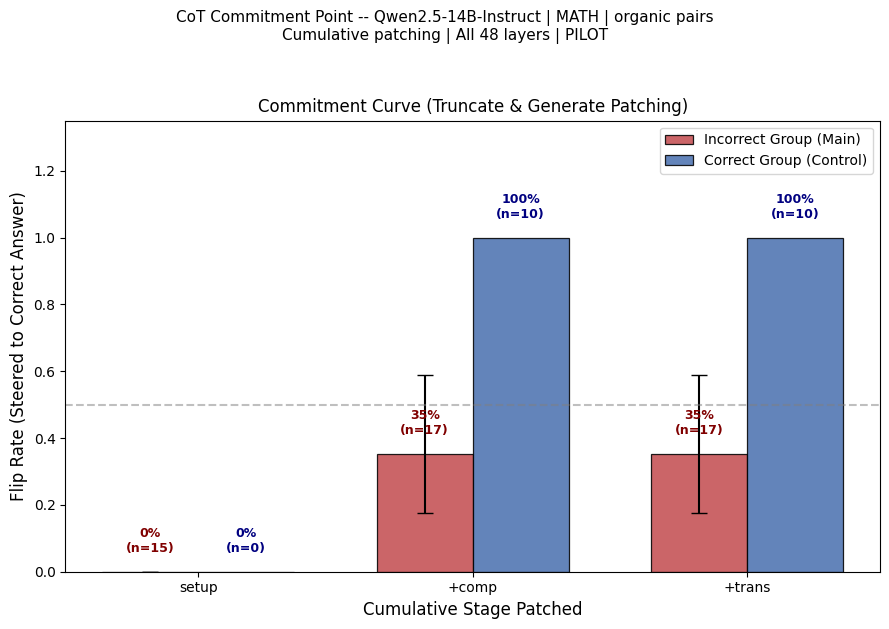

Saved -> /kaggle/working/commitment_curve_cumulative.png


In [21]:
import numpy as np
import matplotlib.pyplot as plt

rates_main  = [counts[s]["flips"] / max(counts[s]["total"], 1) for s in CUMUL_STAGES]
totals_main = [counts[s]["total"] for s in CUMUL_STAGES]

rates_ctrl  = [counts_control[s]["flips"] / max(counts_control[s]["total"], 1) for s in CUMUL_STAGES]
totals_ctrl = [counts_control[s]["total"] for s in CUMUL_STAGES]

ci_data = [bootstrap_ci(counts[s].get("flip_list", [])) for s in CUMUL_STAGES]
ci_los  = [d[0] if not np.isnan(d[0]) else 0 for d in ci_data]
ci_his  = [d[1] if not np.isnan(d[1]) else 0 for d in ci_data]
flip_err = [[max(0.0, r - lo) for r, lo in zip(rates_main, ci_los)],
            [max(0.0, hi - r) for r, hi in zip(rates_main, ci_his)]]

fig, ax = plt.subplots(1, 1, figsize=(9, 6))

x = np.arange(len(CUMUL_STAGES))
width = 0.35

bars_main = ax.bar(x - width/2, rates_main, width, color="#C44E52", edgecolor="black", linewidth=0.9,
              alpha=0.87, yerr=flip_err, capsize=6, error_kw={"linewidth": 1.5}, label="Incorrect Group (Main)")

bars_ctrl = ax.bar(x + width/2, rates_ctrl, width, color="#4C72B0", edgecolor="black", linewidth=0.9,
              alpha=0.87, label="Correct Group (Control)")

for bar, rate, n in zip(bars_main, rates_main, totals_main):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{rate:.0%}\n(n={n})", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#800000")

for bar, rate, n in zip(bars_ctrl, rates_ctrl, totals_ctrl):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{rate:.0%}\n(n={n})", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#000080")

ax.set_xticks(x)
ax.set_xticklabels(["setup", "+comp", "+trans"])
ax.set_ylim(0, 1.35)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax.set_ylabel("Flip Rate (Steered to Correct Answer)", fontsize=12)
ax.set_xlabel("Cumulative Stage Patched", fontsize=12)
ax.set_title("Commitment Curve (Truncate & Generate Patching)", fontsize=12)
ax.legend(fontsize=10, loc="upper right")

run_label = "PILOT" if PILOT_MODE else "FULL RUN"
fig.suptitle(
    f"CoT Commitment Point -- Qwen2.5-14B-Instruct | MATH | organic pairs\n"
    f"Cumulative patching | All {N_LAYERS} layers | {run_label}",
    fontsize=11, y=1.04,
)
plt.tight_layout()
out_path = SAVE_DIR / "commitment_curve_cumulative.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_path}")


In [22]:
import gc
import numpy as np

def run_per_layer(pairs, stage, subset_n=None, source_filter="organic"):
    """Per-layer Truncate & Generate patching."""
    subset = [p for p in pairs if source_filter is None or p.get("source") == source_filter]
    if subset_n:
        subset = subset[:subset_n]
    if not subset:
        print(f"No pairs with source_filter={source_filter!r}"); return {}

    layer_counts = {i: {"flips": 0, "total": 0, "flip_list": []} for i in range(N_LAYERS)}
    skipped = 0
    already_flipped = 0

    est = len(subset) * N_LAYERS * 8 / 60  # FIX Bug 6: 0.4s -> 8s per generate call for 14B NF4 on T4
    print(f"Per-layer: stage='{stage}'  n={len(subset)}  est={est:.1f} min")

    for pair in tqdm(subset, desc=f"per-layer/{stage}"):
        prompt = make_prompt(pair["question"])
        gt     = pair["gt"]
        p_len  = len(tokenizer(prompt, add_special_tokens=False)["input_ids"])

        c_ids = tokenizer(prompt + pair["correct"], add_special_tokens=False, return_tensors="pt")["input_ids"][0]
        w_ids = tokenizer(prompt + pair["wrong"],   add_special_tokens=False, return_tensors="pt")["input_ids"][0]
        c_trace_len = len(c_ids) - p_len

        w_masks = get_stage_masks(pair["wrong"], prompt)
        cumul = build_cumulative_masks(w_masks)
        
        unf_idx = cumul[stage]
        trunc_len = max(unf_idx) + 1 if unf_idx else p_len

        idx = [p for p in unf_idx if (p - p_len) < c_trace_len]
        if not idx:
            skipped += 1
            continue

        truncated_ids = w_ids[:trunc_len]

        # 1. Baseline check
        with torch.no_grad():
            baseline_gen = model.generate(
                truncated_ids.unsqueeze(0).to("cuda:0"),
                attention_mask=torch.ones(1, trunc_len, device="cuda:0"),
                max_new_tokens=150,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
        baseline_pred = extract_gt(tokenizer.decode(baseline_gen[0]))
        
        if baseline_pred is None or answers_match(baseline_pred, gt):
            already_flipped += 1
            continue

        # 2. Per-layer Patching
        store_pass(c_ids)
        full_acts = dict(_acts)
        rel_positions = sorted([p - p_len for p in idx if p >= p_len])

        for layer_i in range(N_LAYERS):
            _acts.clear()
            if layer_i in full_acts:
                _acts[layer_i] = full_acts[layer_i]

            handles = []
            def mk(i):
                def hook(m, inp, out):
                    if i not in _acts: return out
                    h   = _get_h(out)
                    src = _acts[i].to(h.device)
                    h2  = h.clone()
                    for w_rel in rel_positions:
                        abs_pos = p_len + w_rel
                        if abs_pos < h2.shape[1] and abs_pos < src.shape[0]:
                            h2[0, abs_pos] = src[abs_pos]
                    return _set_h(out, h2)
                return hook
            handles.append(model.model.layers[layer_i].register_forward_hook(mk(layer_i)))

            with torch.no_grad():
                patched_gen = model.generate(
                    truncated_ids.unsqueeze(0).to("cuda:0"),
                    attention_mask=torch.ones(1, trunc_len, device="cuda:0"),
                    max_new_tokens=150,
                    do_sample=False,
                    pad_token_id=tokenizer.eos_token_id,
                )

            for h in handles:
                h.remove()

            patched_pred = extract_gt(tokenizer.decode(patched_gen[0]))

            layer_counts[layer_i]["total"] += 1
            if patched_pred is not None and answers_match(patched_pred, gt):
                layer_counts[layer_i]["flips"] += 1
                layer_counts[layer_i]["flip_list"].append(1)
            else:
                layer_counts[layer_i]["flip_list"].append(0)

        _acts.clear()
        del full_acts
        gc.collect()
        torch.cuda.empty_cache()

    print(f"Skipped: {skipped} | Not Committed: {already_flipped}")
    return layer_counts

def plot_per_layer(layer_counts, stage):
    layers     = list(range(N_LAYERS))
    flip_rates = [layer_counts[i]["flips"] / max(layer_counts[i]["total"], 1) for i in layers]

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.plot(layers, flip_rates, "o-", color="#4C72B0", linewidth=1.5, markersize=4)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4)
    ax.set_ylabel("Flip Rate", fontsize=11)
    ax.set_xlabel("Transformer Layer", fontsize=11)
    ax.set_title(f"Per-layer commitment -- cumulative stage: '{stage}'", fontsize=12)

    plt.tight_layout()
    out = SAVE_DIR / f"per_layer_{stage}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out}")
    return layer_counts

try:
    best_stage = max(CUMUL_STAGES, key=lambda s: counts[s]["flips"] / max(counts[s]["total"], 1))
except NameError:
    best_stage = "+computation"
print(f"Recommended stage for per-layer analysis: '{best_stage}'")
print(f"\nRun:")
print(f"  lc = run_per_layer(pairs, stage='{best_stage}')")
print(f"  plot_per_layer(lc, '{best_stage}')")


Recommended stage for per-layer analysis: '+computation'

Run:
  lc = run_per_layer(pairs, stage='+computation')
  plot_per_layer(lc, '+computation')


## 10 · Next steps

If the pilot looks good (clear flip-rate differences across stages):

1. **Scale up** — set `PILOT_MODE = False`, rerun from Cell 7 (collection already done for pilot)
2. **Bootstrap CIs** — resample `pairs` with replacement 1000× to get 95% CI per stage
3. **Layer-level analysis** — instead of patching all 48 layers, patch one layer at a time to localise commitment
4. **Write up** — the commitment curve is your main figure; segmentation stats + flip rates are Table 1

If pilot fails (all stages ~same flip rate, or all ~0):
- Check `find_answer_logit_pos` output in Cell 9 — if None, #### detection is broken
- Check stage breakdown — if one stage has 0 tokens, segmentation is too coarse
- Check `did_flip` — print `pred` and `gt` for a few examples to verify the comparison logic